# **Лабораторная работа №2. Временные ряды**

## Выполнила Китаева Дарья М8О-102БВ-25

Прежде чем начать обработку таблицы я открыла её через Excel, чтобы провести анализ. На первом листе была обнаружена фотография кота на строчках ~84тыс., под самой фотографией не было никаких данных, зато они были справа от таблицы. Я перенесла эти данные обратно в таблицу на место фотографии. Также оценила другие листы: при первом взгляде было обнаружено 5 теоритически пустых листа, а также найдены два скрытых.

[Скриншот](image.png)

Импорты, нужные для корректной работы.

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from scipy import signal
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import optuna

from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.metrics import r2_score

Используем класс из библиотеки pandas - pd.ExcelFile, который представляет Excel-файл в виде объекта и позволяет работать с его содержимым. Применяем его, чтобы впоследствии с помощью атрибута sheet_names получить названия всех страниц в книге.

In [ ]:
xls = pd.ExcelFile("have_fun.xlsx")
print(xls.sheet_names)

Mounted at /content/drive/
['Ëèñò1', 'Лист1', 'ÌÀÈ', 'ýòî', 'ÿ', '!', 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', 'Ëèñò3_ñìåøàííûå_òèïû']


Просматриваем содержимое первого листа(первые две строчки), чтобы убедиться в том, что всё работает и мы можем получить доступ к листу.

In [ ]:
df1 = pd.read_excel("have_fun.xlsx", sheet_name=xls.sheet_names[0])
print(df1.head(2))

   temperature_2m  relative_humidity_2m  precipitation  rain  snowfall  \
0             3.8                    82            0.0   0.0       0.0   
1            -3.0                    70            0.0   0.0       0.0   

   weathercode  wind_speed_10m  surface_pressure                  ds  \
0            3            19.1       1010.000000 2020-01-31 02:00:00   
1            3            24.0        981.900024 2025-02-28 09:00:00   

           city  
0     Ãåëåíäæèê  
1  Áëàãîâåùåíñê  


Далее проходимся таким же образом по каждому листу из нашего файла и проверяем пустой это лист, есть ли в нём строки с NaN или же в нм есть данные и выводим количество строк и столбцов - это нам нужно, чтобы убедиться в том, что это действительно заполненный лист, а не одно слово, которое занимает одну строку и один столбец - такой лист считается пустым.

In [ ]:
for sheet in xls.sheet_names:
    df_test = pd.read_excel("have_fun.xlsx", sheet_name=sheet)
    if df_test.empty:
        print(f"Лист '{sheet}' пустой")
    elif df_test.isna().all().all():
        print(f"Лист '{sheet}' содержит только NaN")
    else:
        print(f"Лист '{sheet}' имеет {df_test.shape[0]} строк и {df_test.shape[1]} столбцов")

Лист 'Ëèñò1' имеет 125124 строк и 10 столбцов
Лист 'Лист1' пустой
Лист 'ÌÀÈ' пустой
Лист 'ýòî' пустой
Лист 'ÿ' пустой
Лист '!' пустой
Лист 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû' имеет 125169 строк и 25 столбцов
Лист 'Ëèñò3_ñìåøàííûå_òèïû' имеет 122736 строк и 10 столбцов


Проходимся по каждой странице и применяем к ним метод dropna для того, тчобы удалить все строки и столбцы, в которых все элементы - NaN. Проверяем, если после нашего удаления остались данные и страница не пустая - добавляем её в словарь и выводим сообщение, иначе - ничего с ним не делаем и просто выводим сообщение. После всего этого выводим количество оставшихся листов с данными, их должно быть 3 штуки из 8 листов, т.к. 5 - пустые.

In [ ]:
all_sheets = pd.read_excel("have_fun.xlsx", sheet_name=None)
non_empty_sheets = {}
for sheet_name, df in all_sheets.items():
    df = df.dropna(how='all').dropna(axis=1, how='all')
    if not df.empty:
        non_empty_sheets[sheet_name] = df
        print(f"Лист '{sheet_name}' не пустой")
    else:
        print(f"Лист '{sheet_name}' пустой")
print(f"\nОсталось листов с данными: {len(non_empty_sheets)}")

Лист 'Ëèñò1' не пустой
Лист 'Лист1' пустой
Лист 'ÌÀÈ' пустой
Лист 'ýòî' пустой
Лист 'ÿ' пустой
Лист '!' пустой
Лист 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû' не пустой
Лист 'Ëèñò3_ñìåøàííûå_òèïû' не пустой

Осталось листов с данными: 3


Всё было оставлено правильно, значит мы можем перейти к исправлению битой кодировки, которая произошла из-за неправильного перевода. Применяем данные исправления для листов, а также для названия городов, которые тоже представляют собой абракадабру.

In [8]:
def fix_encoding(text):
    if isinstance(text, str):
        try:
            return text.encode('latin1').decode('cp1251')
        except:
            return text
    return text

fixed_sheets = {}
for sheet_name, df in non_empty_sheets.items():
    new_name = fix_encoding(sheet_name)
    fixed_sheets[new_name] = df
    print(f"Было: '{sheet_name}', стало:'{new_name}'")

def fix_encoding_df(df):
    df_fixed = df.copy()
    for col in df_fixed.columns:
        if df_fixed[col].dtype == 'object':
            df_fixed[col] = df_fixed[col].apply(lambda x: fix_encoding(x) if isinstance(x, str) else x)
    return df_fixed

for sheet_name, df in fixed_sheets.items():
    fixed_sheets[sheet_name] = fix_encoding_df(df)

Было: 'Ëèñò1', стало:'Лист1'
Было: 'Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû', стало:'Лист2_строковые_NaN_выбросы'
Было: 'Ëèñò3_ñìåøàííûå_òèïû', стало:'Лист3_смешанные_типы'


После того, как мы восстановили кодировку, с помощью метода info() выводим в каких столбцах у нас какие данные(тип данных), а также после этого выводим уникальные названия городов, так как некоторые записаны с ошибкой и нужно увидеть, какие там с ошибкой, а какие нет и сколько их.

In [ ]:
print(fixed_sheets['Лист1'].info())
print("Уникальные города:", fixed_sheets['Лист1']['city'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125124 entries, 0 to 125123
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        123249 non-null  float64       
 1   relative_humidity_2m  125124 non-null  int64         
 2   precipitation         123877 non-null  float64       
 3   rain                  125124 non-null  float64       
 4   snowfall              125124 non-null  float64       
 5   weathercode           125124 non-null  int64         
 6   wind_speed_10m        123872 non-null  float64       
 7   surface_pressure      125124 non-null  float64       
 8   ds                    125124 non-null  datetime64[ns]
 9   city                  125124 non-null  object        
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 9.5+ MB
None
Уникальные города: ['Геленджик' 'Благовещенск' 'БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенскк'
 'б

In [ ]:
print(fixed_sheets['Лист2_строковые_NaN_выбросы'].info())
print("Уникальные города:", fixed_sheets['Лист2_строковые_NaN_выбросы']['city'].unique())

<class 'pandas.core.frame.DataFrame'>
Index: 122717 entries, 0 to 125168
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122036 non-null  object        
 1   relative_humidity_2m  122715 non-null  float64       
 2   precipitation         122028 non-null  object        
 3   rain                  122715 non-null  float64       
 4   snowfall              122715 non-null  float64       
 5   weathercode           122714 non-null  float64       
 6   wind_speed_10m        122365 non-null  object        
 7   surface_pressure      122714 non-null  float64       
 8   ds                    122713 non-null  datetime64[ns]
 9   city                  122712 non-null  object        
 10  Unnamed: 15           107 non-null     object        
 11  Unnamed: 16           108 non-null     object        
 12  Unnamed: 17           106 non-null     object        
 13  Unna

In [ ]:
print(fixed_sheets['Лист3_смешанные_типы'].info())
print("Уникальные города:", fixed_sheets['Лист3_смешанные_типы']['city'].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122736 entries, 0 to 122735
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   temperature_2m        122731 non-null  object        
 1   relative_humidity_2m  122731 non-null  float64       
 2   precipitation         122487 non-null  object        
 3   rain                  122736 non-null  float64       
 4   snowfall              122736 non-null  float64       
 5   weathercode           122736 non-null  object        
 6   wind_speed_10m        122736 non-null  object        
 7   surface_pressure      122736 non-null  float64       
 8   ds                    122736 non-null  datetime64[ns]
 9   city                  122736 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 9.4+ MB
None
Уникальные города: ['Санкт-Петербург' 'Сочи' 'Сычи' 'Счи' 'Соч']


Как мы можем видеть в некоторых колонках встречаются не только числовые значения, но и строковые(там где они не должны быть). Также видим, что города действительно написаны с ошибкой, а во втором листе есть лишние столбцы, которые нужно будет удалить.

In [9]:
df1 = fixed_sheets['Лист1']
df2 = fixed_sheets['Лист2_строковые_NaN_выбросы']
df3 = fixed_sheets['Лист3_смешанные_типы']

In [10]:
df2 = df2.drop(columns=['Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18',
                        'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22',
                        'Unnamed: 23', 'Unnamed: 24'], axis=1)

Удаляем во втором листе лишние столбцы и проверяем, что они действительно удалены.

In [8]:
df2.head(2)

,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,ds,city
0,-6.5,92.0,0,0.0,0.0,3.0,10.8,1000.500000,2019-01-01 00:00:00,Москва
1,-6.8,92.0,0,0.0,0.0,3.0,10.5,1000.299988,2019-01-01 01:00:00,Москва


Далее нам нужно убрать строковые объекты из тех столбцов, в которых их не должно быть в листах 2 и 3 соответственно.

In [11]:
df2['temperature_2m'] = pd.to_numeric(df2['temperature_2m'], errors='coerce')
df2['precipitation'] = pd.to_numeric(df2['precipitation'], errors='coerce')
df2['wind_speed_10m'] = pd.to_numeric(df2['wind_speed_10m'], errors='coerce')

print("Тип данных:", df2['temperature_2m'].dtype)
print("Тип данных:", df2['precipitation'].dtype)
print("Тип данных:", df2['wind_speed_10m'].dtype)

Тип данных: float64
Тип данных: float64
Тип данных: float64


In [12]:
df3['temperature_2m'] = pd.to_numeric(df3['temperature_2m'], errors='coerce')
df3['precipitation'] = pd.to_numeric(df3['precipitation'], errors='coerce')
df3['wind_speed_10m'] = pd.to_numeric(df3['wind_speed_10m'], errors='coerce')

print("Тип данных:", df3['temperature_2m'].dtype)
print("Тип данных:", df3['precipitation'].dtype)
print("Тип данных:", df3['wind_speed_10m'].dtype)

Тип данных: float64
Тип данных: float64
Тип данных: float64


Далее объединяем все 3 листа в один, но перед этим проверяем, что все 3 листа у нас действительно являются дата фреймами.

In [ ]:
print(type(df1))
print(type(df2))
print(type(df3))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


Приводим всё к единому временному индексу и делаем его индексом с помощью set_index делаем его действительно индексом(как 1, 2, 3, ...). Сортируем по этому индексу и выводим первые пару строк и сколько всего получилось строк после объединения.

In [13]:
df = pd.concat([df1, df2, df3], ignore_index=True)
df['ds'] = pd.to_datetime(df['ds'])
df = df.set_index('ds')
df = df.sort_index()
print(df.head(2))
print(df.shape)

            temperature_2m  relative_humidity_2m  precipitation  rain  \
ds                                                                      
2019-01-01            -6.5                  92.0            0.0   0.0   
2019-01-01            -1.8                  85.0            0.0   0.0   

            snowfall weathercode  wind_speed_10m  surface_pressure  \
ds                                                                   
2019-01-01       0.0         3.0            10.8       1000.500000   
2019-01-01       0.0           3            23.5       1015.200012   

                       city  
ds                           
2019-01-01           Москва  
2019-01-01  Санкт-Петербург  
(370577, 9)


In [14]:
df = df.sort_values(['city', 'ds'])
print(df.head(5))

                     temperature_2m  relative_humidity_2m  precipitation  \
ds                                                                         
2019-01-04 16:00:00           -17.4                  70.0            0.0   
2019-01-07 23:00:00           -23.5                  75.0            0.0   
2019-01-15 00:00:00             NaN                  78.0            0.0   
2019-01-25 07:00:00           -14.7                  73.0            0.0   
2019-02-04 19:00:00           -28.4                  62.0            0.0   

                     rain  snowfall weathercode  wind_speed_10m  \
ds                                                                
2019-01-04 16:00:00   0.0       0.0           3             7.2   
2019-01-07 23:00:00   0.0       0.0           2             9.9   
2019-01-15 00:00:00   0.0       0.0           0            12.6   
2019-01-25 07:00:00   0.0       0.0           2            15.9   
2019-02-04 19:00:00   0.0       0.0           0            14.4  

Сортируем по городу и дате.

Смотрим, сколько у нас NaN в каждом столбце.

In [ ]:
print(df.isna().sum())

temperature_2m          4326
relative_humidity_2m       7
precipitation           3705
rain                       2
snowfall                   2
weathercode                3
wind_speed_10m          3091
surface_pressure           3
city                       5
dtype: int64


Сначала убираем все NaN строки, а после убираем строки, в которых нет значения температуры, потому что это наша главная характеристика, по которой мы будем обучать модели, а также убираем строки, в которых нет города, так как не понятно в каком городе нам предсказывать температуру.

In [15]:
df = df.dropna(how='all')
df = df.dropna(subset=['temperature_2m'])
df = df.dropna(subset=['city'])

In [ ]:
print(df.isna().sum())

temperature_2m             0
relative_humidity_2m       0
precipitation           3649
rain                       0
snowfall                   0
weathercode                0
wind_speed_10m          3045
surface_pressure           0
city                       0
dtype: int64


Проверяем, что в нужных нам столбцах нет NaN, в других они могут быть, так как мы удаляли строковые значения.

Проверяем какие различные города у нас есть и просматриваем полных их список, чтобы быть точно уверенными, что мы ничего не пропустим. Составляем список из того, что на что нам нужно будет заменить и после заменяем и проверяем, что у нас осталось только 6 нужных нам городов.

In [ ]:
print(df['city'].unique())

['БЛАГОВЕЩЕНСК' 'Благовещенс' 'Благовещенск' 'Благовещенскк' 'ГЕЛЕНДЖИК'
 'Геленджи' 'Геленджик' 'Геленджикк' 'Москва' 'Находка' 'Санкт-Петербург'
 'Соч' 'Сочи' 'Счи' 'Сычи' 'благовещенск' 'геленджик']


In [16]:
city_fix = {
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    'Благовещенскк':'Благовещенск',
    'ГЕЛЕНДЖИК':'Геленджик',
    'Геленджи':'Геленджик',
    'Геленджикк':'Геленджик',
    'благовещенск':'Благовещенск',
    'геленджик':'Геленджик',
    'Сычи': 'Сочи',
    'Счи': 'Сочи',
    'Соч': 'Сочи'
}

df['city'] = df['city'].replace(city_fix)
print(df['city'].unique())

['Благовещенск' 'Геленджик' 'Москва' 'Находка' 'Санкт-Петербург' 'Сочи']


Удаляем столбцы rain и snowfall, так как в столбце precipitation - осадки уже учтены и дождь, и снег.

In [17]:
df = df.drop(columns=['rain', 'snowfall'])

Перед тем как перевести наши почасовые данные в дневные мы должны проверить, что у нас нет выбросов, а если есть, то удалить их для дальнейшей обработки.

In [ ]:
print(df['temperature_2m'].describe())

count    366248.000000
mean          8.727016
std          12.278450
min         -49.990098
25%           1.000000
50%          10.000000
75%          17.900000
max          79.974214
Name: temperature_2m, dtype: float64


Как мы можем видеть выбросы действительно есть, так как температура -50 и +80 это что-то нереальное для всех 6 городов, что у нас есть.

In [18]:
df_hourly = df.copy()
df_hourly.loc[df_hourly['temperature_2m'] > 45, 'temperature_2m'] = np.nan
df_hourly.loc[df_hourly['temperature_2m'] < -45, 'temperature_2m'] = np.nan
print(df_hourly['temperature_2m'].isna().sum())

765


Мы удалили 765 выбросов и можем переходить к следующему пункту, а именно - интерполяции.

In [19]:
df[['precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'surface_pressure', 'weathercode']] = df_hourly[['precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'surface_pressure', 'weathercode']].interpolate(method='linear')
df = df.ffill().bfill()
print(df.shape)
print(df.isna().sum())

/tmp/ipykernel_13475/2266818301.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[['precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'surface_pressure', 'weathercode']] = df_hourly[['precipitation', 'wind_speed_10m', 'relative_humidity_2m', 'surface_pressure', 'weathercode']].interpolate(method='linear')


(366248, 7)
temperature_2m          0
relative_humidity_2m    0
precipitation           0
weathercode             0
wind_speed_10m          0
surface_pressure        0
city                    0
dtype: int64


Далее нам нужно перевести данные из почасового прогноза в дневной, так как на дневных данных можно будет лучше увидеть аномалии - выбросы, а также вместо анализа 360тыс строк нужно будет проанализировать меньшее количество - около 15тыс, также от часов к дням, потому нам нужно сделать прогноз на неделю вперёд,для этого достаточно дневной гранулярности, часовые данные избыточны и создают шум, который ухудшает качество прогноза.

In [20]:
df = df.reset_index()
print(df.columns)

Index(['ds', 'temperature_2m', 'relative_humidity_2m', 'precipitation',
       'weathercode', 'wind_speed_10m', 'surface_pressure', 'city'],
      dtype='object')


In [21]:
df_daily = df.groupby(['city', pd.Grouper(key='ds', freq='D')]).agg(
    temp_mean=('temperature_2m', 'mean'),
    temp_min=('temperature_2m', 'min'),
    temp_max=('temperature_2m', 'max'),
    humidity=('relative_humidity_2m', 'mean'),
    precip=('precipitation', 'sum'),
    wind=('wind_speed_10m', 'mean'),
    pressure=('surface_pressure', 'mean')
).reset_index()

In [ ]:
print(df_daily.head())
print(df_daily.shape)

           city         ds  temp_mean   temp_min  temp_max   humidity  precip  \
0  Благовещенск 2019-01-01 -14.037500 -20.900000     -10.7  63.083333     0.0   
1  Благовещенск 2019-01-02 -18.391667 -23.200001     -11.4  72.875000     0.0   
2  Благовещенск 2019-01-03 -18.586957 -23.200001     -13.8  69.695652     0.0   
3  Благовещенск 2019-01-04 -20.756522 -24.100000     -16.9  74.956522     0.0   
4  Благовещенск 2019-01-05 -19.880000 -24.500000     -12.0  72.480000     0.0   

        wind     pressure  
0  13.400000  1008.362498  
1  10.904167  1010.916667  
2   8.491304  1010.369568  
3   8.200000  1004.491296  
4  10.820000  1007.604001  
(15342, 9)


Как мы можем видеть у нас действительно стало 15тыс строк, значит всё верно.

Проверяем, сколько на каждый город у нас уникальных дат. 2557 дней это примерно 7 лет, так что у нас всё верно, и ещё можем заметить, что во всех городах одинаковое количество дней.

In [ ]:
print(df_daily.groupby('city')['ds'].nunique())

city
Благовещенск       2557
Геленджик          2557
Москва             2557
Находка            2557
Санкт-Петербург    2557
Сочи               2557
Name: ds, dtype: int64


## **Графики**

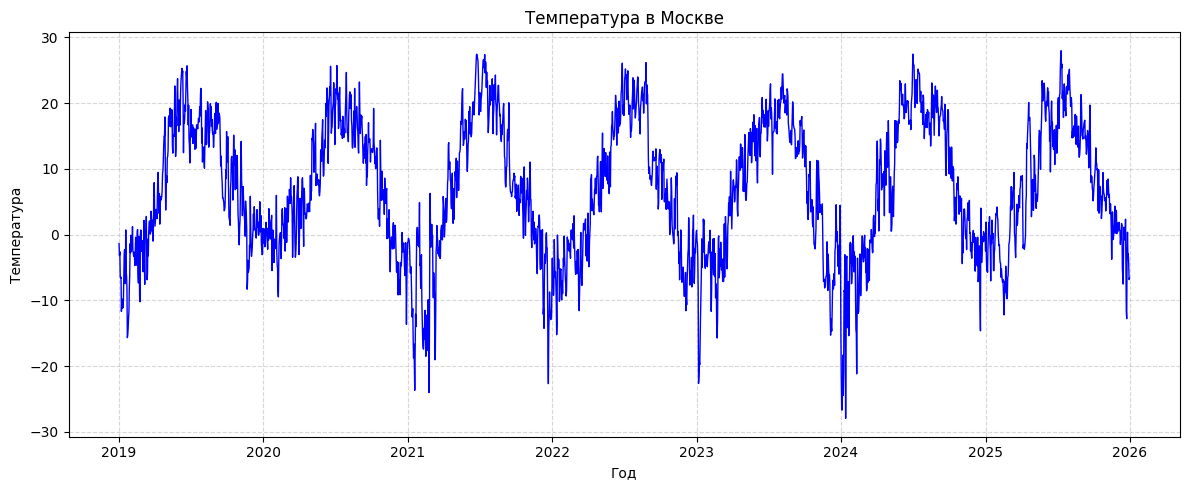

In [ ]:
moscow = df_daily[df_daily['city'] == 'Москва']

plt.figure(figsize=(12, 5))
plt.plot(moscow['ds'], moscow['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Москве')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

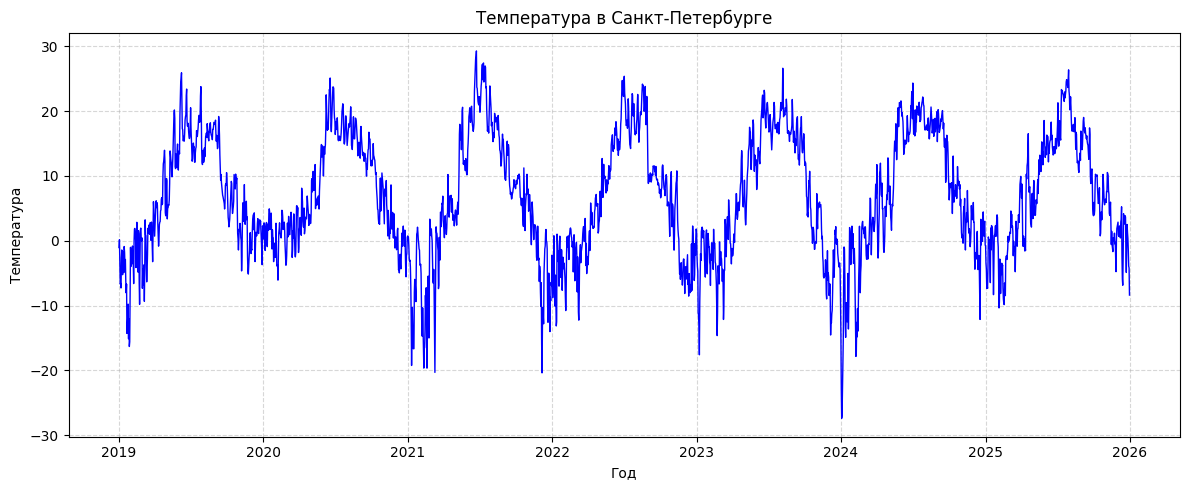

In [ ]:
spb = df_daily[df_daily['city'] == 'Санкт-Петербург']

plt.figure(figsize=(12, 5))
plt.plot(spb['ds'], spb['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Санкт-Петербурге')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

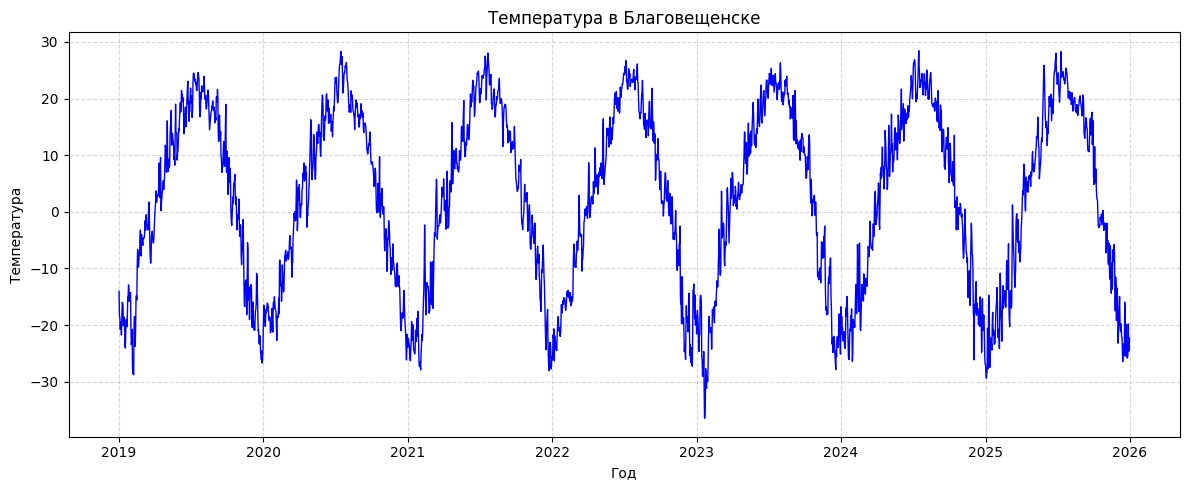

In [ ]:
blago = df_daily[df_daily['city'] == 'Благовещенск']

plt.figure(figsize=(12, 5))
plt.plot(blago['ds'], blago['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Благовещенске')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

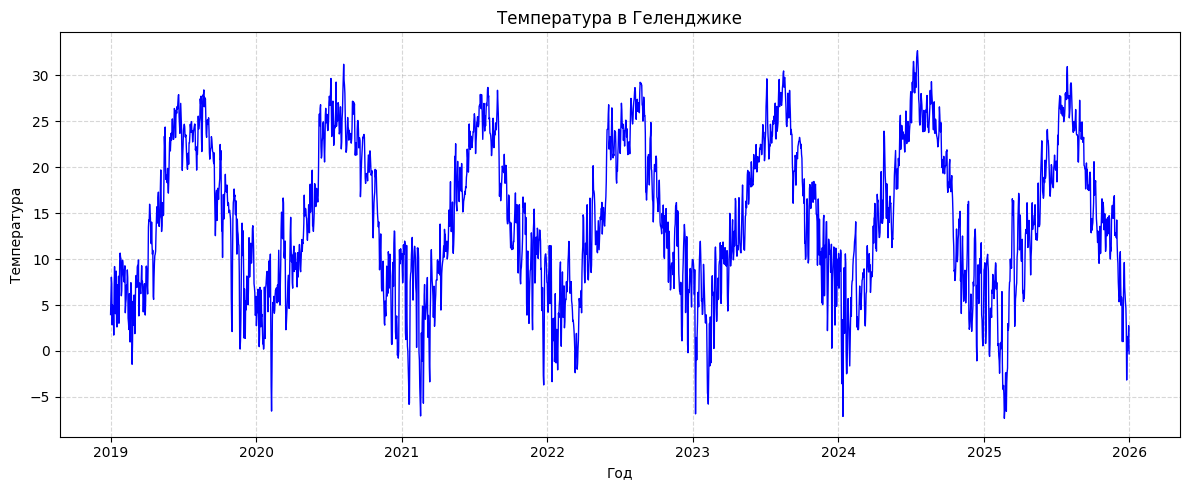

In [ ]:
gele = df_daily[df_daily['city'] == 'Геленджик']

plt.figure(figsize=(12, 5))
plt.plot(gele['ds'], gele['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Геленджике')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

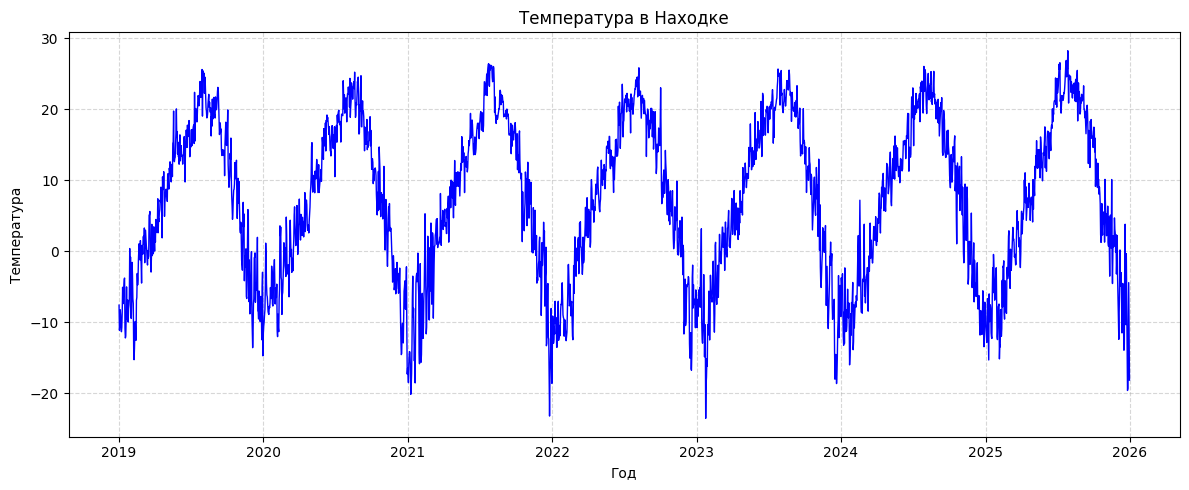

In [ ]:
na = df_daily[df_daily['city'] == 'Находка']

plt.figure(figsize=(12, 5))
plt.plot(na['ds'], na['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Находке')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

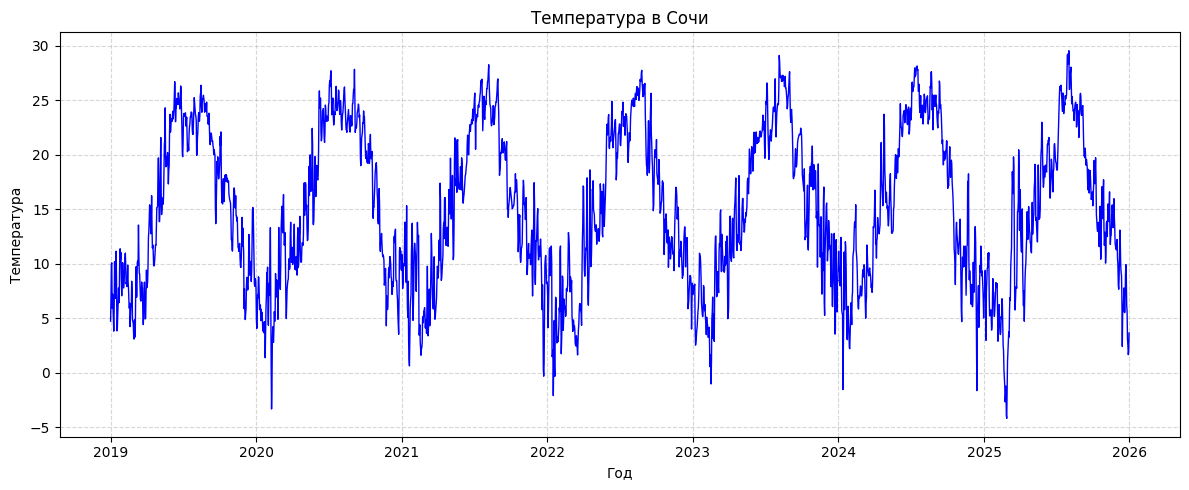

In [ ]:
sochi = df_daily[df_daily['city'] == 'Сочи']

plt.figure(figsize=(12, 5))
plt.plot(sochi['ds'], sochi['temp_mean'], color='blue', linewidth=1)
plt.title('Температура в Сочи')
plt.xlabel('Год')
plt.ylabel('Температура')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Как мы можем видеть из этих графиков у нас есть годичная сезонность: летом тепло, зимой холодно. Также можем заметить, что из года в год температура примерно одинаковая, а значит тренда нет - нет ни убывающей, ни возрастающей тенденции.

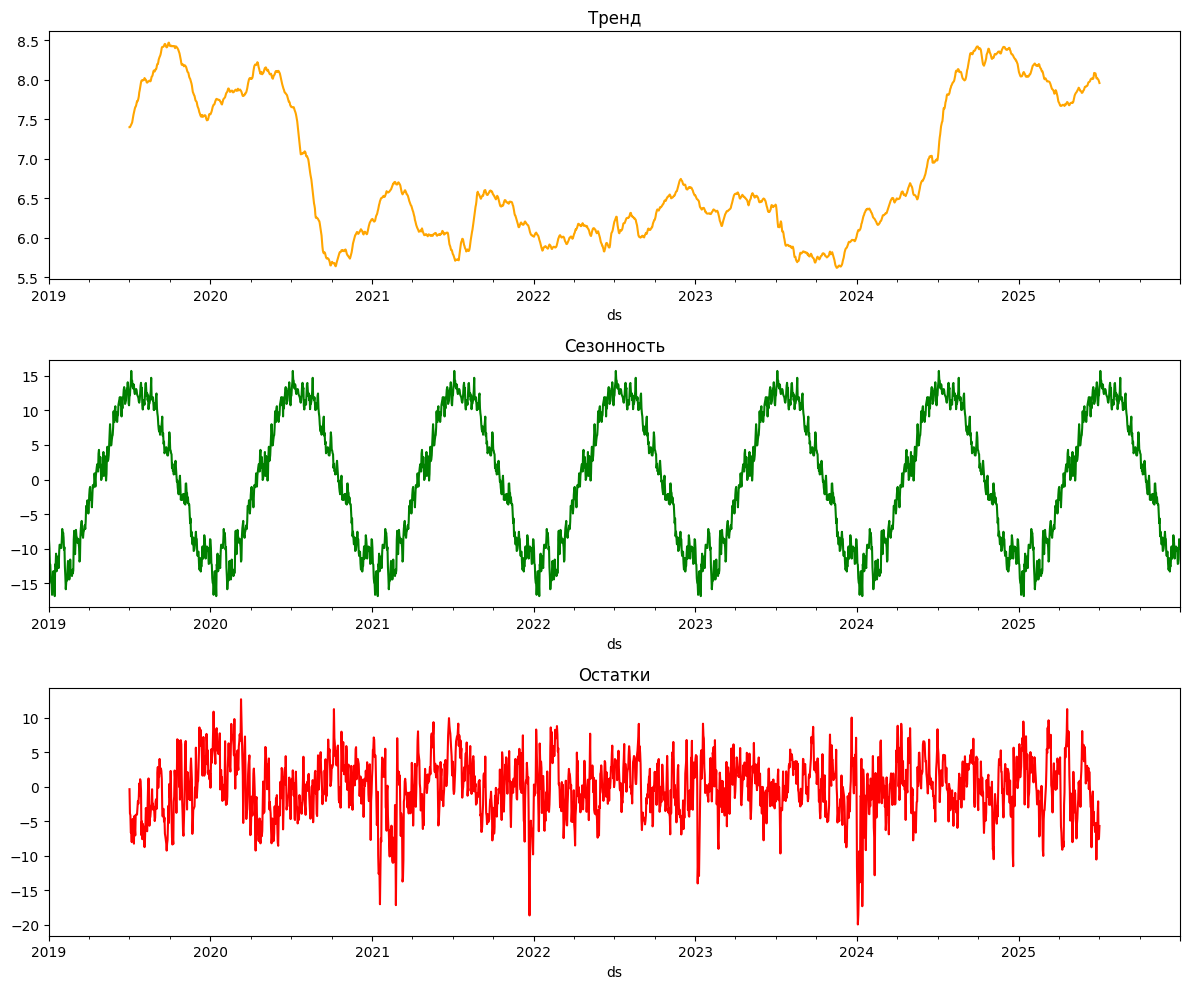

In [25]:
moscow_series = df_daily[df_daily['city'] == 'Москва'].set_index('ds')['temp_mean']
moscow_series = moscow_series.asfreq('D').interpolate()

decomp = seasonal_decompose(moscow_series, model='additive', period=365)

fig, axes = plt.subplots(3, 1, figsize=(12, 10))
decomp.trend.plot(ax=axes[0], title='Тренд', color='orange')
decomp.seasonal.plot(ax=axes[1], title='Сезонность', color='green')
decomp.resid.plot(ax=axes[2], title='Остатки', color='red')
plt.tight_layout()
plt.show()

По графику тренда мы видим, что он представляет собой небольшое корыто, он должен пресдтавлять собой прямую линию, так как температура в москве не сильно менялась из года в год, что подтверждает ADF-тест, так могло быть из-за недостаточной длины ряда. Сезонность прекрасно видна на графике, что сейчас, что на том графике, что представлен выше. Остатки это данные минус сезонность и тренд и по хорошему они должны колебаться около нуля или быть в районе +-10, но как мы видим в некоторых моментах у нас он доходит и до -20. Это может быть связано с тем, что в данных есть, как годовая, так и недельная сезонность. 

Мы используем ADF-тест, чтобы понять, зависит ли температура от времени. Если p-value < 0.05 — ряд стационарный, значит, тренда нет и можно строить прогноз.

In [22]:
city_data = df_daily[df_daily['city'] == 'Москва'].set_index('ds')['temp_mean'].dropna()
result = adfuller(city_data)
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print(f'Critical values: {result[4]}')

ADF Statistic: -3.2249
p-value: 0.0186
Critical values: {'1%': np.float64(-3.4329251045454816), '5%': np.float64(-2.8626776757726495), '10%': np.float64(-2.567375627472622)}


 Ряд стационарный, значит, средняя температура за 6 лет не изменилась, резкого потепления или похолодания нет

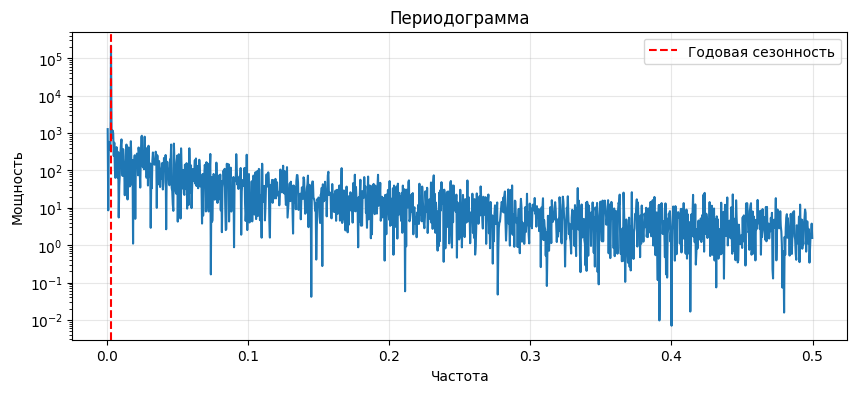

In [27]:
series = moscow_series.dropna()

f, Pxx = signal.periodogram(series, fs=1.0)

plt.figure(figsize=(10, 4))
plt.semilogy(f[1:], Pxx[1:])
plt.title('Периодограмма')
plt.xlabel('Частота')
plt.ylabel('Мощность')
plt.grid(True, alpha=0.3)

plt.axvline(x=1/365, color='red', linestyle='--', label='Годовая сезонность')
plt.legend()
plt.show()

In [41]:
df_daily = df_daily.sort_values(['city', 'ds']).reset_index(drop=True)

df_daily['target_t7'] = df_daily.groupby('city')['temp_mean'].shift(-7)

df_daily['lag_7'] = df_daily.groupby('city')['temp_mean'].shift(7)
df_daily['lag_14'] = df_daily.groupby('city')['temp_mean'].shift(14)
df_daily['lag_1'] = df_daily.groupby('city')['temp_mean'].shift(1)

df_daily['roll_mean_7'] = df_daily.groupby('city')['temp_mean'].transform(lambda x: x.shift(1).rolling(7).mean())

df_daily['dayofyear'] = df_daily['ds'].dt.dayofyear
df_daily['month'] = df_daily['ds'].dt.month
df_daily['dayofweek'] = df_daily['ds'].dt.dayofweek
df_daily['day_sin'] = np.sin(2 * np.pi * df_daily['dayofyear'] / 365)
df_daily['day_cos'] = np.cos(2 * np.pi * df_daily['dayofyear'] / 365)

df_daily = df_daily.dropna()

Нам нужно, чтобы модель понимала, какая температура была раньше (лаги), какая погода по сезону (день года, месяц) и скользящие средние, без этого она будет просто угадывать.

In [26]:
train = df_daily[df_daily['ds'] < '2024-01-01']
val = df_daily[(df_daily['ds'] >= '2024-01-01') & (df_daily['ds'] < '2025-01-01')]
test = df_daily[df_daily['ds'] >= '2025-01-01']

print(f"Train: {train.shape[0]}, Val: {val.shape[0]}, Test: {test.shape[0]}")

features = ['lag_1', 'lag_7', 'lag_14', 'roll_mean_7', 'day_sin', 'day_cos', 'month', 'dayofweek']

train_encoded = pd.get_dummies(train, columns=['city'], prefix='city')
val_encoded = pd.get_dummies(val, columns=['city'], prefix='city')
test_encoded = pd.get_dummies(test, columns=['city'], prefix='city')
print(train_encoded)

X_train = train_encoded[features + [c for c in train_encoded.columns if c.startswith('city_')]]
y_train = train_encoded['target_t7']
X_val = val_encoded[features + [c for c in val_encoded.columns if c.startswith('city_')]]
y_val = val_encoded['target_t7']
X_test = test_encoded[features + [c for c in test_encoded.columns if c.startswith('city_')]]
y_test = test_encoded['target_t7']

Train: 10872, Val: 2196, Test: 2148
              ds  temp_mean   temp_min  temp_max   humidity  precip  \
14    2019-01-15 -19.227273 -23.200001     -13.9  60.863636     0.0   
15    2019-01-16 -23.762500 -27.600000     -20.6  61.458333     0.0   
16    2019-01-17 -24.060000 -28.100000     -18.0  52.600000     0.0   
17    2019-01-18 -20.939131 -25.299999     -15.4  58.565217     0.0   
18    2019-01-19 -19.175000 -23.500000     -14.7  70.375000     1.0   
...          ...        ...        ...       ...        ...     ...   
14606 2023-12-27  12.208696  10.800000      15.2  75.304348     4.2   
14607 2023-12-28   6.208333   1.200000      10.7  67.916667     0.0   
14608 2023-12-29   5.570833  -0.300000      10.7  47.500000     0.0   
14609 2023-12-30   8.495833   4.900000      14.3  47.250000     0.0   
14610 2023-12-31   8.395833   5.000000      11.3  65.500000     0.4   

            wind     pressure  target_t7      lag_7  ...  month  dayofweek  \
14      9.272727  1003.186365 -18

Для временных рядов нельзя перемешивать данные случайно — это приведёт к утечке будущего в прошлое. Поэтому мы делим строго по датам: на train идёт всё до 2024 года, на val — 2024 год, на test — 2025 год. Модель не понимает слова, поэтому превращаем названия городов в цифры, создаём отдельные колонки, где 1, если это нужный город, 0 — если нет.

In [28]:
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_val)
print(f"Decision Tree MAE: {mean_absolute_error(y_val, dt_pred):.2f}")

Decision Tree MAE: 3.26


Дерево решений - самая простая модель, её результат - 3,26 градуса - это значение, на которое модель ошибается при предсказании температуры.

In [30]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
print(f"Random Forest MAE: {mean_absolute_error(y_val, rf_pred):.2f}")

Random Forest MAE: 2.84


Это 100 деервьев решений, которые предсказывают результаты независимо друг от друга, а потом значение усредняется. Это делает модель точнее, чем одно дерево. Результат 2,84 лучше, чем тот, что был у одного дерева. Чем больше деревьев тем меньше риск переобучения.

In [32]:
xgb = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_val)
print(f"XGBoost MAE: {mean_absolute_error(y_val, xgb_pred):.2f}")

XGBoost MAE: 2.80


Результат отличается не сильно от Леса, но тем не менее лучше.

In [ ]:
import optuna

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
    }
    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return mean_absolute_error(y_val, pred)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print(f"Best MAE: {study.best_value:.2f}")
print(f"Best params: {study.best_params}")

best_xgb = XGBRegressor(**study.best_params, random_state=42)
best_xgb.fit(X_train, y_train)
best_pred = best_xgb.predict(X_test)
print(f"XGBoost MAE на тесте: {mean_absolute_error(y_test, best_pred):.2f}")

[I 2026-05-11 16:53:38,718] A new study created in memory with name: no-name-2825aa6c-d5e7-4164-a722-9b0c162c235d
[I 2026-05-11 16:53:43,466] Trial 0 finished with value: 2.886493474576958 and parameters: {'n_estimators': 295, 'max_depth': 7, 'learning_rate': 0.010265442748947832, 'subsample': 0.7967432438802173}. Best is trial 0 with value: 2.886493474576958.
[I 2026-05-11 16:53:44,274] Trial 1 finished with value: 2.790306539917123 and parameters: {'n_estimators': 203, 'max_depth': 4, 'learning_rate': 0.07544179990548773, 'subsample': 0.9408954464270034}. Best is trial 1 with value: 2.790306539917123.
[I 2026-05-11 16:53:44,812] Trial 2 finished with value: 2.809483296543987 and parameters: {'n_estimators': 259, 'max_depth': 4, 'learning_rate': 0.08304586196634235, 'subsample': 0.9222617017691683}. Best is trial 1 with value: 2.790306539917123.
[I 2026-05-11 16:53:45,419] Trial 3 finished with value: 2.962421377830337 and parameters: {'n_estimators': 129, 'max_depth': 7, 'learning_ra

Best MAE: 2.75
Best params: {'n_estimators': 248, 'max_depth': 3, 'learning_rate': 0.098202880664084, 'subsample': 0.7670120607940945}
XGBoost (Optuna) MAE на тесте: 3.00


У XGBoost есть настройки, от которых зависит точность. Вместо того чтобы подбирать их вручную, мы используем optuna, который сам перебирает разные варианты и находит лучшие. Лучшая ошибка была 2,75, что меньше, чем без подбора настроек.

In [ ]:
def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

def directional_accuracy(y_today, y_true_t7, y_pred_t7):
    real_change = y_true_t7 - y_today
    pred_change = y_pred_t7 - y_today
    correct = np.sign(real_change) == np.sign(pred_change)
    return np.mean(correct) * 100

def directional_r2(y_today, y_true_t7, y_pred_t7):
    real_change = y_true_t7 - y_today
    pred_change = y_pred_t7 - y_today
    if len(real_change) < 2 or np.std(real_change) == 0 or np.std(pred_change) == 0:
        return np.nan
    corr = np.corrcoef(real_change, pred_change)[0, 1]
    return corr**2

y_today_test = test['temp_mean'].values[:len(y_test)]

mae = mean_absolute_error(y_test, best_pred)
mape = mean_absolute_percentage_error(y_test, best_pred) * 100
wape_val = wape(y_test, best_pred)
dir_acc = directional_accuracy(y_today_test, y_test, best_pred)
dir_r2 = directional_r2(y_today_test, y_test, best_pred)
r2 = r2_score(y_test, best_pred)

print(f"MAE: {mae:.2f}°C")
print(f"MAPE: {mape:.1f}%")
print(f"WAPE: {wape_val:.1f}%")
print(f"Directional Accuracy: {dir_acc:.1f}%")
print(f"Directional R2: {dir_r2:.3f}")
print(f"R2: {r2:.3f}")

Directional R2: 0.388


R2 равный 39% означает то, что модель объясняет 39% изменчивости недельной температуры, что подтверждает хаотичность погодных изменений.

## Вывод
В ходе работы был очищен и подготовлен временной ряд погодных данных для 6 городов. Исходные данные содержали ошибки ручного ввода: текстовые значения вместо чисел, опечатки в названиях городов, пропуски и выбросы. Все эти проблемы были обнаружены и исправлены.
Данные переведены с часовых на дневные, так как для прогноза на неделю вперёд дневная гранулярность достаточна, а часовые данные создают лишний шум.
Проведён анализ временного ряда, который показал, что ADF-тест показал стационарность, наличие годовой сезонности, остатки случайны.
Для прогноза температуры на 7 дней созданы признаки, такие как лаги 1, 7, 14 дней, скользящее среднее за 7 дней, день года, месяц, день недели. Данные разделены хронологически, train — до 2024 года, val — 2024 год, test — 2025 год.
Обучены три модели:
- Дерево решений: MAE = 3.26
- Случайный лес: MAE = 2.84
- XGBoost: MAE = 2.8